In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

# Feed-forward Neural Network Model

The neural network model can be described as follows:

$$
\begin{equation}
    \begin{split}
        \boldsymbol{a}^{[0]} &= \boldsymbol{x}\\
        \boldsymbol{a}^{[l+1]} &= \boldsymbol{\sigma}\left(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\right)\,,\quad \quad l=0:L-1`
    \end{split}
\end{equation}
$$

where $\boldsymbol{x}\in\mathbb{R}^{n_1}$ is a datapoint, $\boldsymbol{b}^{[l+1]}$ is the bias vector at layer $l$, $W^{[l+1]}$ is the matrix of weights that layer $l+1$ applies to the output of layer $l$ and $L$ is the total number of layers.

For any $l=1:L$, $\boldsymbol{\sigma}:\mathbb{R}^{n_l}\rightarrow\mathbb{R}^{n_l}$ is the non-linear activation function applied component-wise.

For any $l=1:L$

$$
\begin{align*}
    &\boldsymbol{z}^{[l+1]} = W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\\
    \implies &\boldsymbol{a}^{[l+1]} = \boldsymbol{\sigma}(\boldsymbol{z}^{[l+1]})
\end{align*}
$$

In [2]:
# Implementing multi-layer perceptron 
class MLP(nn.Module):
    def __init__(self, in_features=10, hidden_features=10, out_features=1, num_layers=50):
        super(MLP, self).__init__()
        
        self.layers = nn.ModuleList()
        
        # Layer 1: Linear
        self.layers.append(nn.Linear(in_features=in_features, out_features=hidden_features))
        
        # Layers 2 to L-1: Linear
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(in_features=hidden_features, out_features=hidden_features))
            
        # Layer L: Linear Output
        self.layers.append(nn.Linear(in_features=hidden_features, out_features=out_features))

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)

        x = F.tanh(self.layers[0](x))
        # Layer 1 to L-1: Linear -> Tanh
        for i in range(1,len(self.layers) - 1):
            x = F.tanh(self.layers[i](x))
            
        # Layer L: Output Layer
        x = self.layers[-1](x)
        
        return x

The total loss function $\mathcal{L}$ is function of the actual class labels $y_{i}$ and the network output for all the datapoints $\boldsymbol{a}^{[L]}_i$.

# Backpropagation

To help the network learn, the weights are updated using common gradient-based optimizers such as stochastic gradient descent or Adam. For this, the gradient of the loss function w.r.t. the parameters must be accurately calculated using the backpropagation chain rule.

The gradient of the loss function w.r.t. $\boldsymbol{b}^{[l]}$ can be calculated as follows:
$$
\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \boldsymbol{b}^{[l]}} = \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}} \cdot \frac{\partial\boldsymbol{a}^{[L]}}{\partial \boldsymbol{a}^{[L-1]}}\dots\frac{\partial \boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}}\cdot\frac{\partial \boldsymbol{a}^{[l]}}{\partial \boldsymbol{b}^{[l]}}
\end{align*}
$$

Here,

$$
\begin{align*}
    \frac{\partial\boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}} = \text{diag}(\sigma'(\boldsymbol{z}^{[l+1]})) W^{[l+1]}
\end{align*}
$$

# Vanishing Gradient Problem

To find the gradient of the loss function with respect to the parameters in an earlier layer, we can observe that the per-layer transition Jacobians are continuously multiplied across the **depth** of the network. The gradient reaching layer $l$ is therefore a product of $L-l$ such Jacobians.

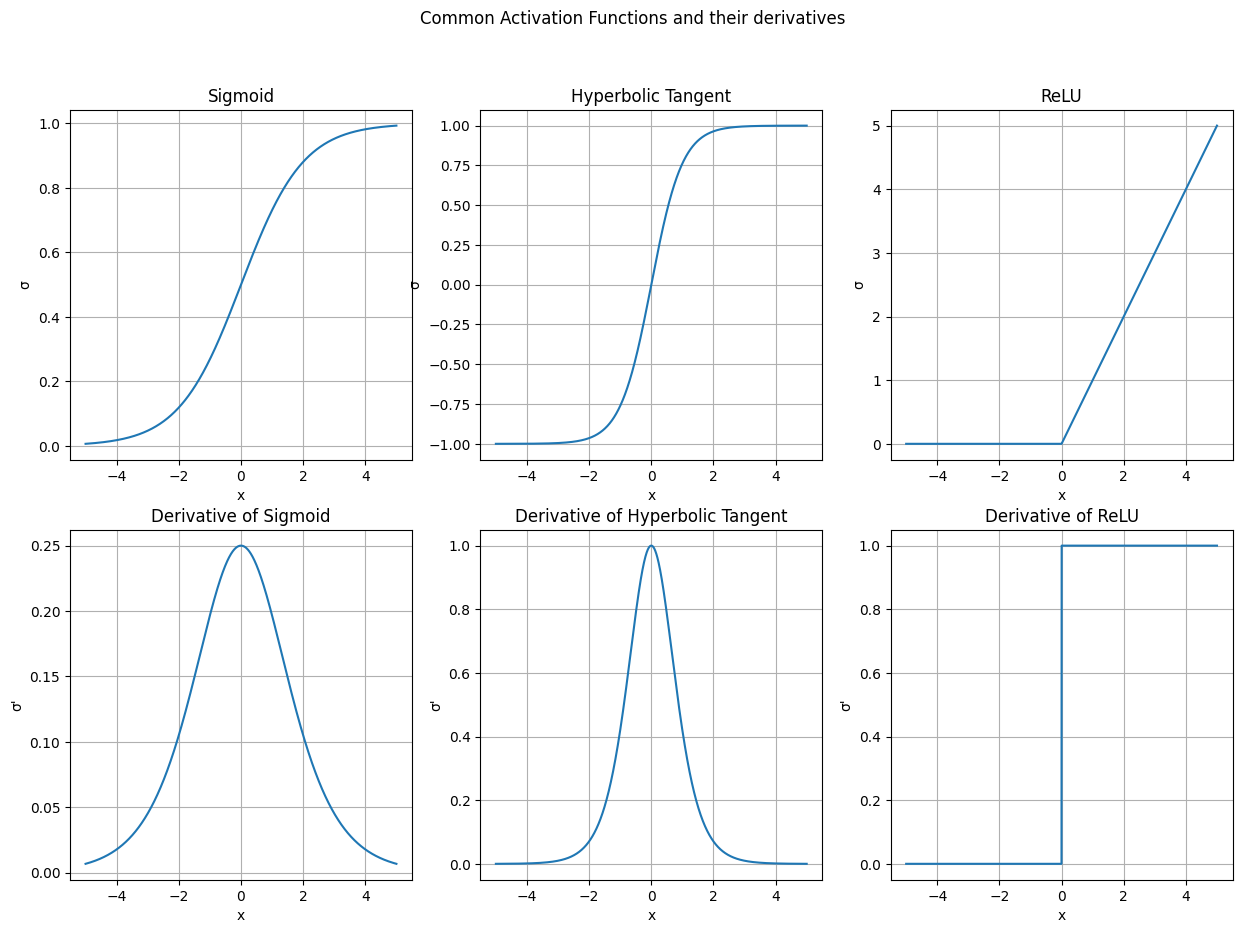

In [3]:
fig, ax = plt.subplots(nrows=2,ncols=3,figsize=(15,10))
grid = torch.linspace(-5,5,2000)

ax[0,0].plot(grid.numpy(),nn.Sigmoid()(grid))
ax[0,0].set_title("Sigmoid")
ax[0,0].grid(True)
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("σ")

ax[0,1].plot(grid.numpy(),nn.Tanh()(grid))
ax[0,1].set_title("Hyperbolic Tangent")
ax[0,1].grid(True)
ax[0,1].set_xlabel("x")
ax[0,1].set_ylabel("σ")

ax[0,2].plot(grid.numpy(),nn.ReLU()(grid))
ax[0,2].set_title("ReLU")
ax[0,2].grid(True)
ax[0,2].set_xlabel("x")
ax[0,2].set_ylabel("σ")

ax[1,0].plot(grid.numpy(),nn.Sigmoid()(grid)*(1-nn.Sigmoid()(grid)))
ax[1,0].set_title("Derivative of Sigmoid")
ax[1,0].grid(True)
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("σ'")


ax[1,1].plot(grid.numpy(),1-(nn.Tanh()(grid))**2)
ax[1,1].set_title("Derivative of Hyperbolic Tangent")
ax[1,1].grid(True)
ax[1,1].set_xlabel("x")
ax[1,1].set_ylabel("σ'")


ax[1,2].plot(grid.numpy(), torch.where(grid < 0, 0.0, 1.0))
ax[1,2].set_title("Derivative of ReLU")
ax[1,2].grid(True)
ax[1,2].set_xlabel("x")
ax[1,2].set_ylabel("σ'")

plt.suptitle("Common Activation Functions and their derivatives")
plt.show()

Now, if $|\sigma'(t)|<1$ and the weight matrices have spectral norm of order $1$ or less, then each factor in this product has norm less than $1$, so the product decays with depth. As a result, the gradient norm $\|\partial\mathcal{L}/\partial W^{[l]}\|$ is smaller for early layers (small $l$) than for layers near the output. This is the **vanishing gradient problem**.

<!-- It is important to note that this is a phenomenon across **layers (depth)**, not across training **epochs (time)**: the decay is present even at initialization, before any optimization step is taken. Its consequence over training is that the early layers receive a near-zero gradient signal at every step, so they are barely updated and the network fails to optimize the early parameters efficiently. -->

For instance, 

$$
\begin{align*}
    ||\frac{\partial\boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}}||_2 &\leq ||\text{diag}(\sigma'(\boldsymbol{z}^{[l+1]}))||_2||W^{[l+1]}||_2\\
    &=\left(\max_{i}|[\text{diag}(\sigma'(\boldsymbol{z}^{[l+1]}))]_{ii}|\right)||W^{[l+1]}||_2\\
    &\leq 1
\end{align*}
$$

The early layers receive a near-zero gradient signal at every step, so they are barely updated and the network fails to optimize the parameters efficiently.

## Random Datapoint

In [4]:
# Dummy datapoint
x = torch.randn(1, 10)          # a random data point with 10 features
target = torch.tensor([[1.0]])

In [5]:
x.shape

torch.Size([1, 10])

In [6]:
# Multi-layer perceptron
model = MLP(in_features=10, hidden_features=10, out_features=1, num_layers=50)

# Forward pass
output = model(x)
loss_function = nn.MSELoss()
loss = loss_function(output, target)

# Backward pass
loss.backward()

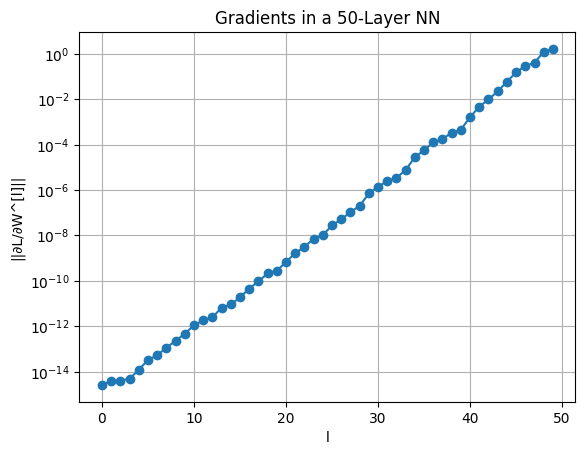

In [7]:
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()  # Extract gradient norms for each layer
    gradient_norms.append(norm)

# Plotting the norm of the gradient w.r.t the layers
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer NN")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

## MNIST Dataset

In [8]:
transform = transforms.Compose([transforms.ToTensor(), 
                            transforms.Normalize((0.5,), (0.5,))])

In [9]:
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainset.data.shape

torch.Size([60000, 28, 28])

In [10]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Get one batch of images and labels
images, labels = next(iter(trainloader))

In [ ]:
# multi-layer perceptron
model = MLP(in_features=784, hidden_features=128, out_features=10,num_layers=50)

# Use CrossEntropyLoss for classification (combines LogSoftmax and NLLLoss)
loss_function = nn.CrossEntropyLoss()

# Forward pass
output = model(images)
loss = loss_function(output, labels)

# Backward pass
loss.backward()

# Extract and plot gradient norms
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()
    gradient_norms.append(norm)

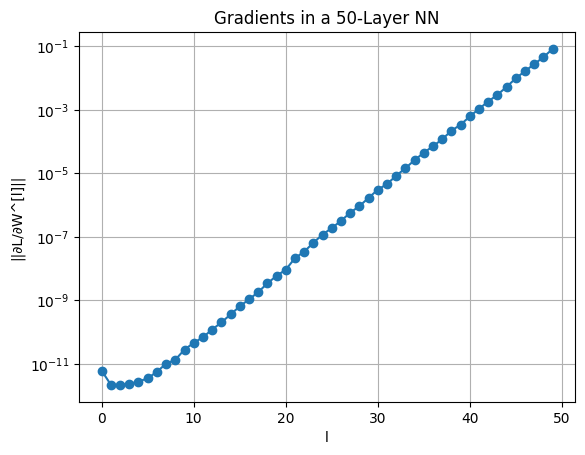

In [12]:
# Plotting the results
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer NN")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

# ResNet

The ResNet architecture can be described as follows:

$$
\begin{equation}
    \begin{split}
        \boldsymbol{a}^{[0]} &= \boldsymbol{x}\\
        \boldsymbol{a}^{[l+1]} &= \boldsymbol{a}^{[l]}+\boldsymbol{\sigma}\left(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\right)\,,\quad \quad l=0:L-1
    \end{split}
\end{equation}
$$

where $\boldsymbol{x}\in\mathbb{R}^{n_1}$ is a datapoint, $\boldsymbol{b}^{[l+1]}$ is the bias vector at layer $l$, $W^{[l+1]}$ is the matrix of weights that layer $l+1$ applies to the output of layer $l$ and $L$ is the total number of layers.

**Backpropagation for ResNet:**

The gradient of the loss function w.r.t. $\boldsymbol{b}^{[l]}$ can be calculated as follows:
$$
\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \boldsymbol{b}^{[l]}} = \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}} \cdot \frac{\partial\boldsymbol{a}^{[L]}}{\partial \boldsymbol{a}^{[L-1]}}\dots\frac{\partial \boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}}\cdot\frac{\partial \boldsymbol{a}^{[l]}}{\partial \boldsymbol{b}^{[l]}}
\end{align*}
$$

where 
$$
\begin{align*}
    \frac{\partial\boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}} = I+\text{diag}(\sigma'(\boldsymbol{z}^{[l+1]})) W^{[l+1]}
\end{align*}
$$

This gives

$$
\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \boldsymbol{b}^{[l]}} = \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}} + \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}}\sum\left(\text{Cross-terms}\right)
\end{align*}
$$

The gradient from the final layer propagates directly to layer $l$ without attenuation. This structural modification guarantees that the core gradient signal remains robust, overcoming the traditional vulnerabilities of deep networks.

In [13]:
# Implementing ResNet
class ResNet(nn.Module):
    def __init__(self, in_features=10, hidden_features=10, out_features=1, num_layers=50):
        super(ResNet, self).__init__()
        
        self.layers = nn.ModuleList()
        
        # Layer 1: Linear
        self.layers.append(nn.Linear(in_features=in_features, out_features=hidden_features))
        
        # Layers 2 to L-1: Linear
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(in_features=hidden_features, out_features=hidden_features))
            
        # Layer L: Linear Output
        self.layers.append(nn.Linear(in_features=hidden_features, out_features=out_features))

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)

        x = F.tanh(self.layers[0](x))
        # Layer 1 to L-1: Linear -> Tanh
        for i in range(1,len(self.layers) - 1):
            x = x + F.tanh(self.layers[i](x))              # Adding Skip connections
            
        # Layer L: Output Layer
        x = self.layers[-1](x)
        
        return x

## Random Datapoint

In [ ]:
# Multi-layer ResNet model
model = ResNet(in_features=10, hidden_features=10, out_features=1, num_layers=50)

# Forward pass
output = model(x)
loss_function = nn.MSELoss()
loss = loss_function(output, target)

# Backward pass
loss.backward()

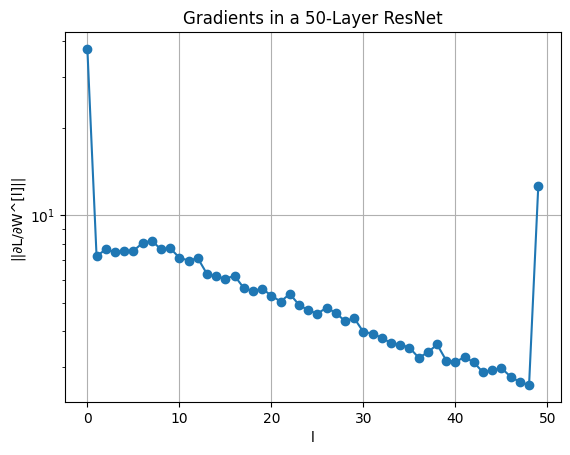

In [19]:
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()  # Extract gradient norms for each layer
    gradient_norms.append(norm)

# Plotting the norm of the gradient w.r.t the layers
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer ResNet")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

## MNIST Dataset

In [ ]:
# multi-layer ResNet model
model = ResNet(in_features=784, hidden_features=128, out_features=10,num_layers=50)

# Use CrossEntropyLoss for classification (combines LogSoftmax and NLLLoss)
loss_function = nn.CrossEntropyLoss()

# Forward pass
output = model(images)
loss = loss_function(output, labels)

# Backward pass
loss.backward()


# Extract and plot gradient norms
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()
    gradient_norms.append(norm)

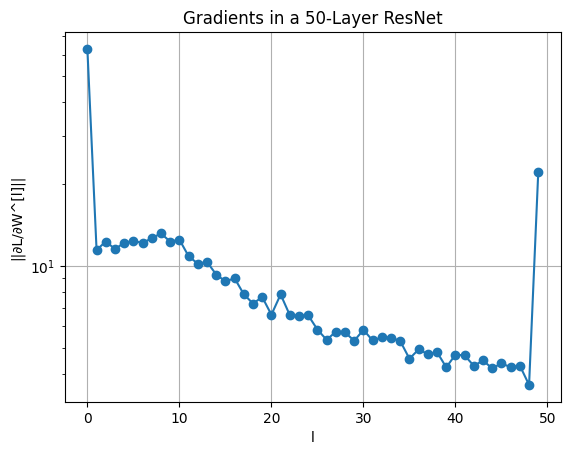

In [23]:
# Plotting the results
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer ResNet")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

# Comparing Accuracies on MNIST dataset

# Continuous-Time Limit: Neural ODEs

Let $\boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]}) = \boldsymbol{\sigma}(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]})$ with parameters $\boldsymbol{\theta}^{[l]} = (W^{[l+1]}, \boldsymbol{b}^{[l+1]})$ where $l=0:L-1\,$.

The standard Neural Net consists of learning the map:

$$
\boldsymbol{a}^{[l+1]} = \boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]})
$$

whereas ResNet learns the residual between input and output
$$
\boldsymbol{a}^{[l+1]} = \boldsymbol{a}^{[l]} + \boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]})
$$


Let us write the residual block as a function $\boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]}) = \boldsymbol{\sigma}(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]})$ with parameters $\boldsymbol{\theta}^{[l]} = (W^{[l+1]}, \boldsymbol{b}^{[l+1]})$, and introduce an explicit step size $\Delta l$:

$$
\boldsymbol{a}^{[l+1]} = \boldsymbol{a}^{[l]} + \Delta l\,\boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]}).
$$

The standard ResNet is recovered when $\Delta l = 1$. Rearranging the terms, we get

$$
\frac{\boldsymbol{a}^{[l+1]} - \boldsymbol{a}^{[l]}}{\Delta l} = \boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]}).
$$

Now, identifying the layer index $l$ with a continuous "depth" variable $t$ and taking the limit $\Delta t \to 0$, the left-hand side becomes a derivative and the discrete state $\boldsymbol{a}^{[l]}$ becomes a continuous trajectory $\boldsymbol{a}(t)$:

$$
\boxed{\ \frac{d\boldsymbol{a}(t)}{dt} = \boldsymbol{\mathcal{F}}(\boldsymbol{a}(t), t;\theta),\qquad \boldsymbol{a}(0) = \boldsymbol{x}.\ }
$$


Starting from the input layer $\boldsymbol{a}(0)$, we can define the output layer $\boldsymbol{a}(T)$ to be the solution to this ODE initial value problem at some time $T$. This value can be computed by a black-box differential equation solver, which evaluates the hidden unit dynamics f wherever necessary to determine the solution with the desired accuracy.

In other words, a deep residual network is a **forward Euler discretization** of an ODE, and the "depth" of the network is the integration interval $[0,T]$. This is the **Neural ODE** viewpoint: instead of stacking a fixed number of layers, we define the dynamics $\boldsymbol{f}$ and hand the integration to any ODE solver (Euler, RK4, an adaptive solver, ...), choosing accuracy vs. cost at will.

**Vanishing gradients as numerical stability.** The transition Jacobian of one Euler step is

$$
\frac{\partial \boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}} = I + \Delta t\,\frac{\partial \boldsymbol{f}}{\partial \boldsymbol{a}},
$$

so backpropagation multiplies factors of the form $\big(I + \Delta t\,\partial_a\boldsymbol{f}\big)$. This is precisely the **amplification matrix of the forward Euler method**: the gradient neither vanishes nor explodes exactly when the eigenvalues of $I + \Delta t\,\partial_a\boldsymbol{f}$ stay near the unit circle, which is the usual linear stability condition for explicit integrators. The plain network corresponds to dropping the $I$ (no skip), so the product collapses; the ResNet keeps the $I$ and is therefore the stable, identity-anchored discretization. The vanishing-gradient pathology is the optimization-side face of an **unstable integration scheme**.

**Backpropagation in the limit: the adjoint method.** Define the continuous adjoint $\boldsymbol{a}^{\dagger}(t) = \partial\mathcal{L}/\partial\boldsymbol{a}(t)$, the continuous analogue of the discrete $\boldsymbol{\delta}^{[l]}$. Letting $\Delta t \to 0$ in the discrete recursion $\boldsymbol{\delta}^{[l]} = \big(I + \Delta t\,\partial_a\boldsymbol{f}\big)^{\!\top}\boldsymbol{\delta}^{[l+1]}$ yields a linear ODE solved **backward in time**:

$$
\frac{d\boldsymbol{a}^{\dagger}(t)}{dt} = -\left(\frac{\partial \boldsymbol{f}}{\partial \boldsymbol{a}}\right)^{\!\top}\boldsymbol{a}^{\dagger}(t),\qquad \boldsymbol{a}^{\dagger}(T) = \frac{\partial \mathcal{L}}{\partial \boldsymbol{a}(T)},
$$

and the parameter gradient is the integral

$$
\frac{\partial \mathcal{L}}{\partial \theta} = -\int_{0}^{T} \boldsymbol{a}^{\dagger}(t)^{\!\top}\,\frac{\partial \boldsymbol{f}}{\partial \theta}\,dt.
$$

Because the adjoint is itself an ODE, the gradient can be obtained by integrating backward **without storing every intermediate activation**, giving $O(1)$ memory in depth — a key practical advantage over storing the full stack of layer activations in a discrete deep network.